# Ejercicio 2

    Utilice para entrenamiento y prueba los conjuntos de datos concent_trn.csv y 
concent tst.csv, que consisten en dos clases distribuidas en forma
concéntrica, como muestra la Figura 1. Determine la estructura de una red
de tipo perceptrón multicapa que resulte más apropiada para resolver este
problema. Represente gráficamente, con diferentes colores, el resultado de la
clasificación realizada por el perceptrón multicapa.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *

(1499, 2)
(1499,)


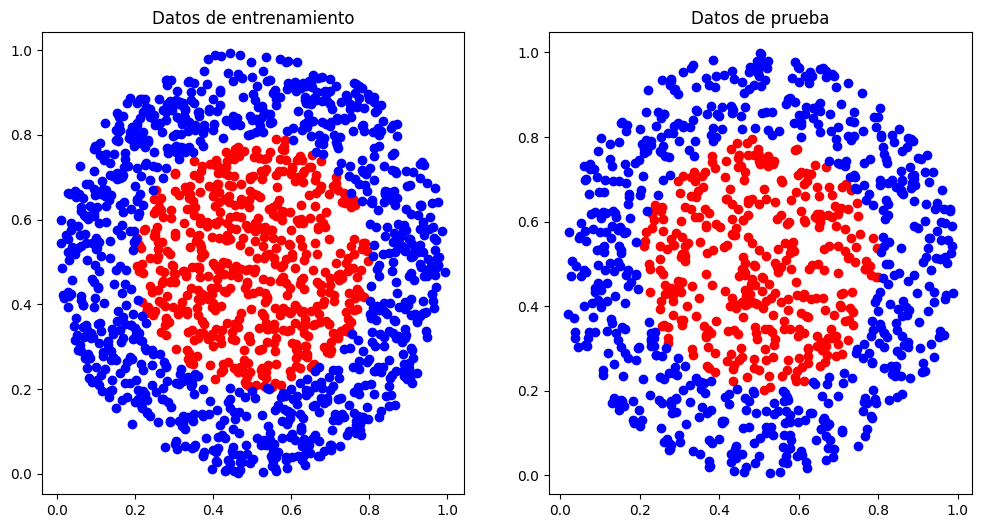

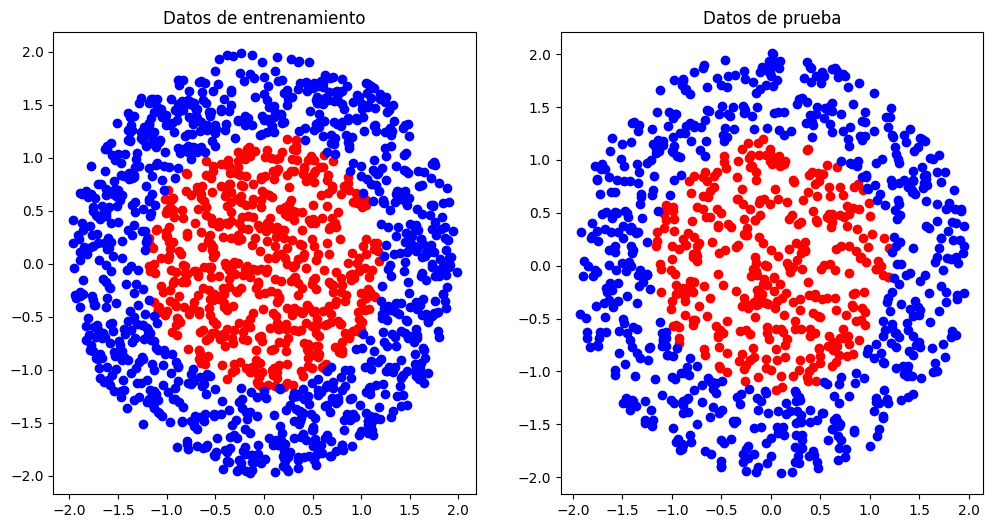

In [7]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'concent_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'concent_tst.csv'))

X_train, X_test = np.array(X_train), np.array(X_test)
y_train, y_test = np.array(y_train), np.array(y_test)

y_train_flatted = y_train.flatten()
y_test_flatted = y_test.flatten()
print(X_train.shape)
print(y_train_flatted.shape)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Datos de entrenamiento")
plt.scatter(X_train[y_train_flatted == -1][:, 0], X_train[y_train_flatted == -1][:, 1], color='red')
plt.scatter(X_train[y_train_flatted == 1][:, 0], X_train[y_train_flatted == 1][:, 1], color='blue')

plt.subplot(1,2,2)
plt.title("Datos de prueba")
plt.scatter(X_test[y_test_flatted == -1][:, 0], X_test[y_test_flatted == -1][:, 1], color='red')
plt.scatter(X_test[y_test_flatted == 1][:, 0], X_test[y_test_flatted == 1][:, 1], color='blue')
plt.show()

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Datos de entrenamiento")
plt.scatter(X_train_norm[y_train_flatted == -1][:, 0], X_train_norm[y_train_flatted == -1][:, 1], color='red')
plt.scatter(X_train_norm[y_train_flatted == 1][:, 0], X_train_norm[y_train_flatted == 1][:, 1], color='blue')

plt.subplot(1,2,2)
plt.title("Datos de prueba")
plt.scatter(X_test_norm[y_test_flatted == -1][:, 0], X_test_norm[y_test_flatted == -1][:, 1], color='red')
plt.scatter(X_test_norm[y_test_flatted == 1][:, 0], X_test_norm[y_test_flatted == 1][:, 1], color='blue')
plt.show()

In [ ]:
model = neural_network(
    layers_config = [(5, 'symmetry sigmoid'), (5, 'symmetry sigmoid'), (1, 'symmetry sigmoid')],
    size_input = X_train_norm.shape[1],
    max_epoch=100,
    learning_rate=0.01,
    error_threshold=1e-3)

model.fit(X_train_norm, y_train)

y_pred = model.transform(X_test_norm)

print(model.score(X_test_norm, y_test))

0.989


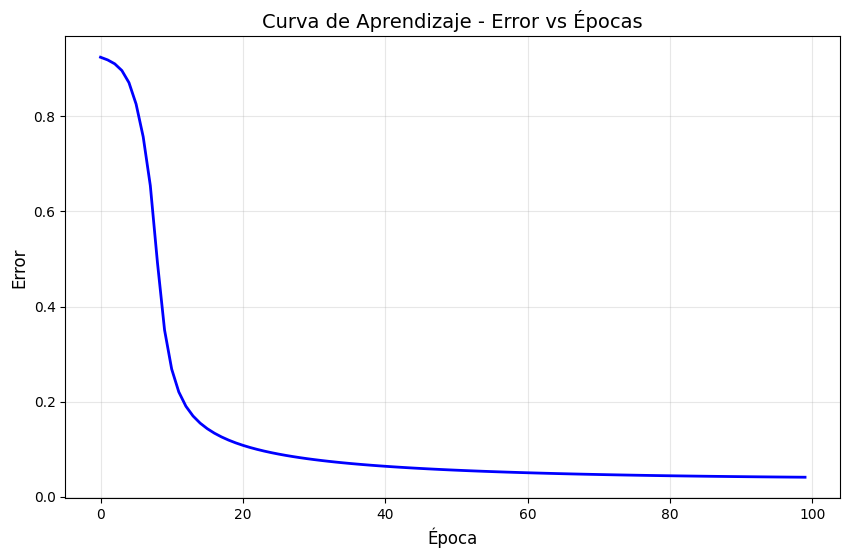

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
def graficar_malla(model, plt):
    x_min, x_max = -2.5, 2.5
    y_min, y_max = -2.5, 2.5

    resolucion = 0.05 #delta x y delta y para hacer la maya

    xx=np.arange(x_min, x_max, resolucion)
    yy=np.arange(y_min, y_max, resolucion)

    #creamos la malla 2d
    X_malla, Y_malla = np.meshgrid(xx, yy)

    #para cada punto de la malla predecimos su clase

    puntos_aplanados = np.c_[X_malla.ravel(), Y_malla.ravel()] #los aplana para recorrerlos

    predicciones = []
    for punto in puntos_aplanados:
        punto_fila = punto.reshape(1,-1) #nuestra red espera una fila
        salida = model.transform(punto_fila)
        predicciones.append(salida.flatten()[0]) #retorna array nuestra salida

    #convertimos a una malla
    Z = np.array(predicciones).reshape(X_malla.shape)

    cont = plt.contourf(X_malla, Y_malla, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(cont)
    for i in range(len(X_test_norm)):
        if y_test[i] == 1:
            plt.scatter(X_test_norm[i, 0], X_test_norm[i, 1], color='blue', s=100, edgecolors='black')
        else:
            plt.scatter(X_test_norm[i, 0], X_test_norm[i, 1], color='red', s=100, edgecolors='black')




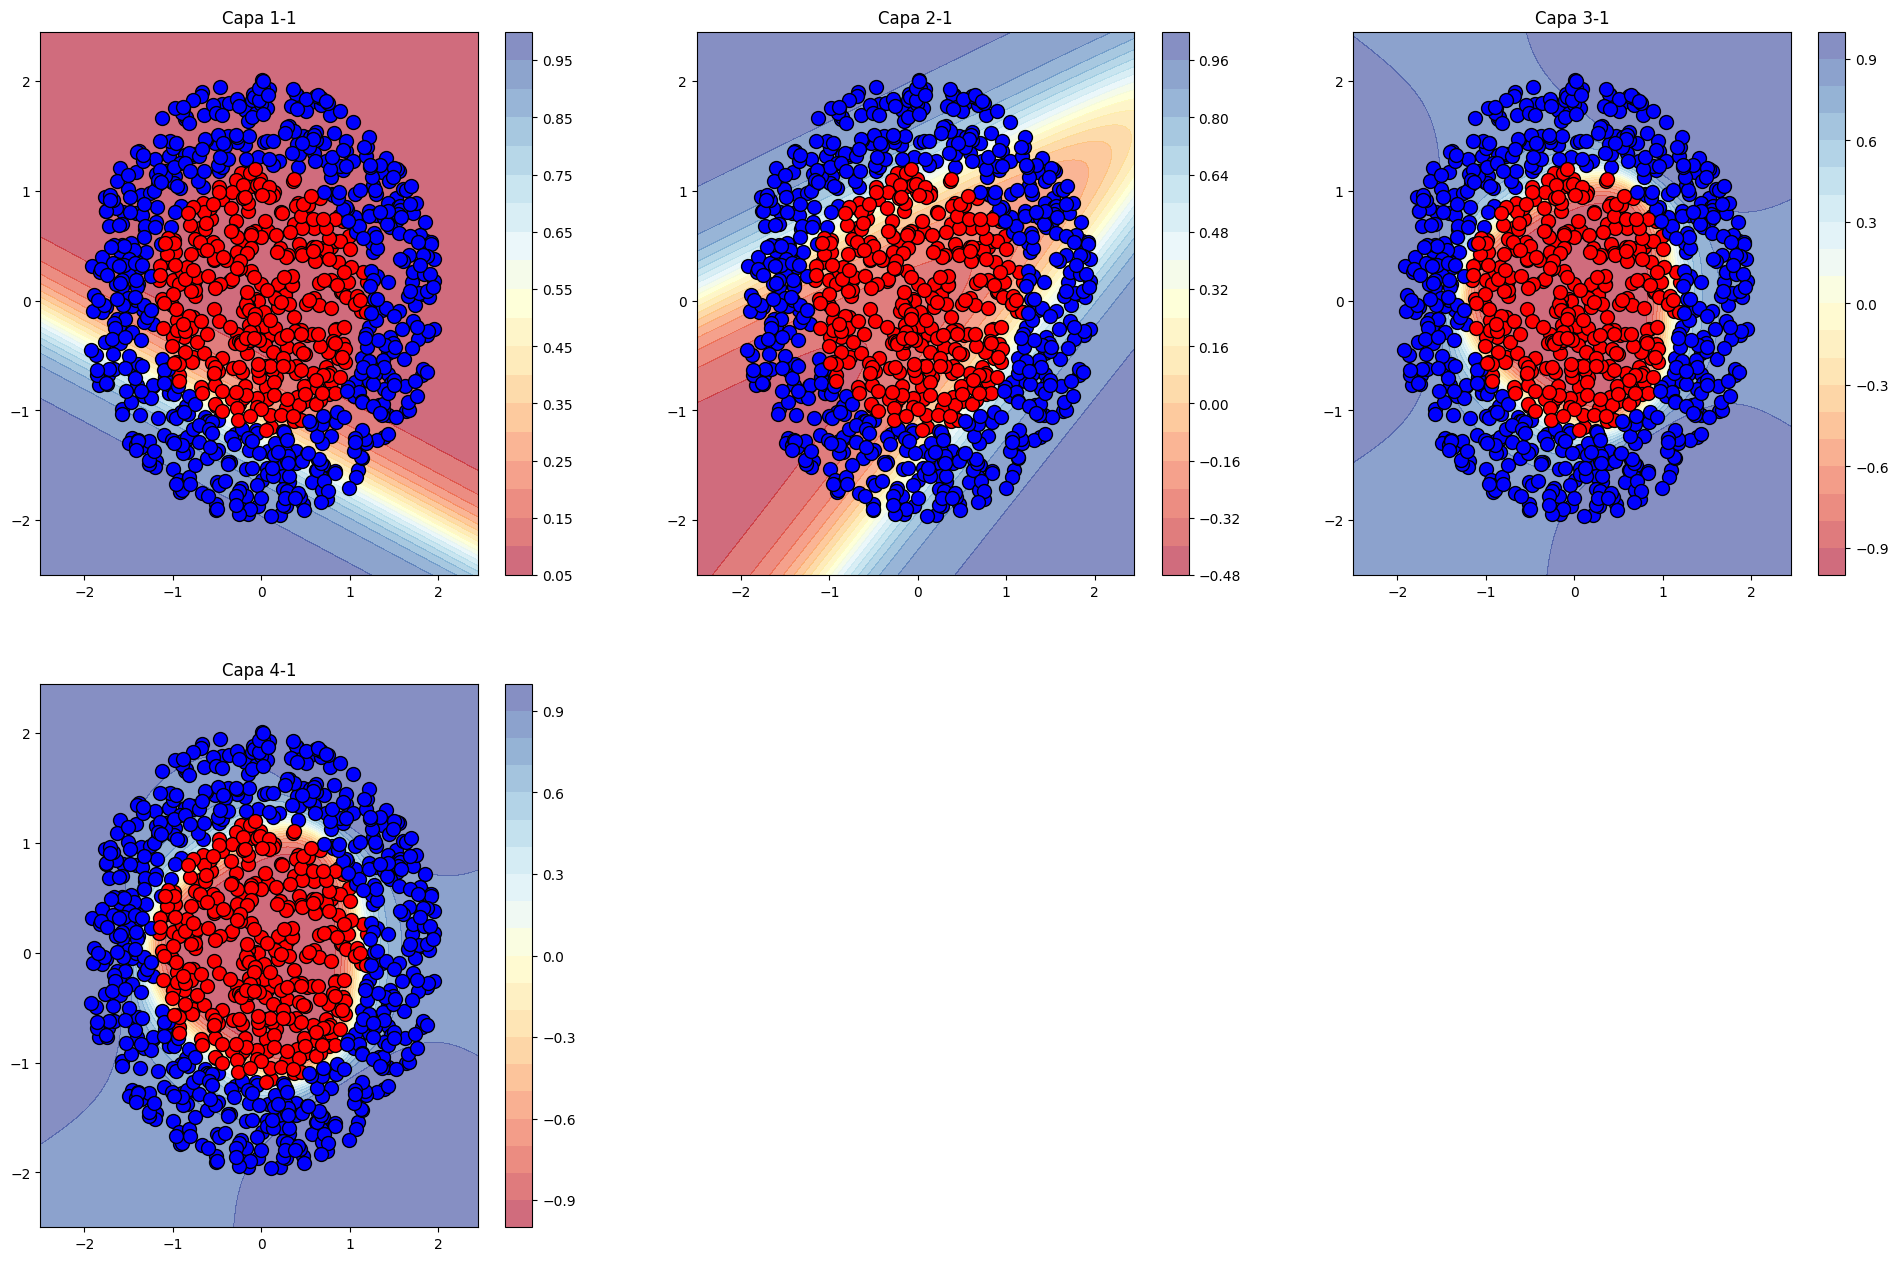

In [11]:
combinaciones = [
    1, 2, 3, 4,
]
plt.figure(figsize=(24,24))

for i in range(len(combinaciones)):
    plt.subplot(3,3,i+1)
    model = neural_network(
        layers_config = [
            (combinaciones[i], 'symmetry sigmoid'),
            (1, 'symmetry sigmoid')
        ],
        size_input = X_train_norm.shape[1],
        max_epoch=100,
        learning_rate=0.01,
        error_threshold=1e-3)

    plt.title(f"Capa {combinaciones[i]}-1")
    model.fit(X_train_norm, y_train)
    graficar_malla(model, plt)

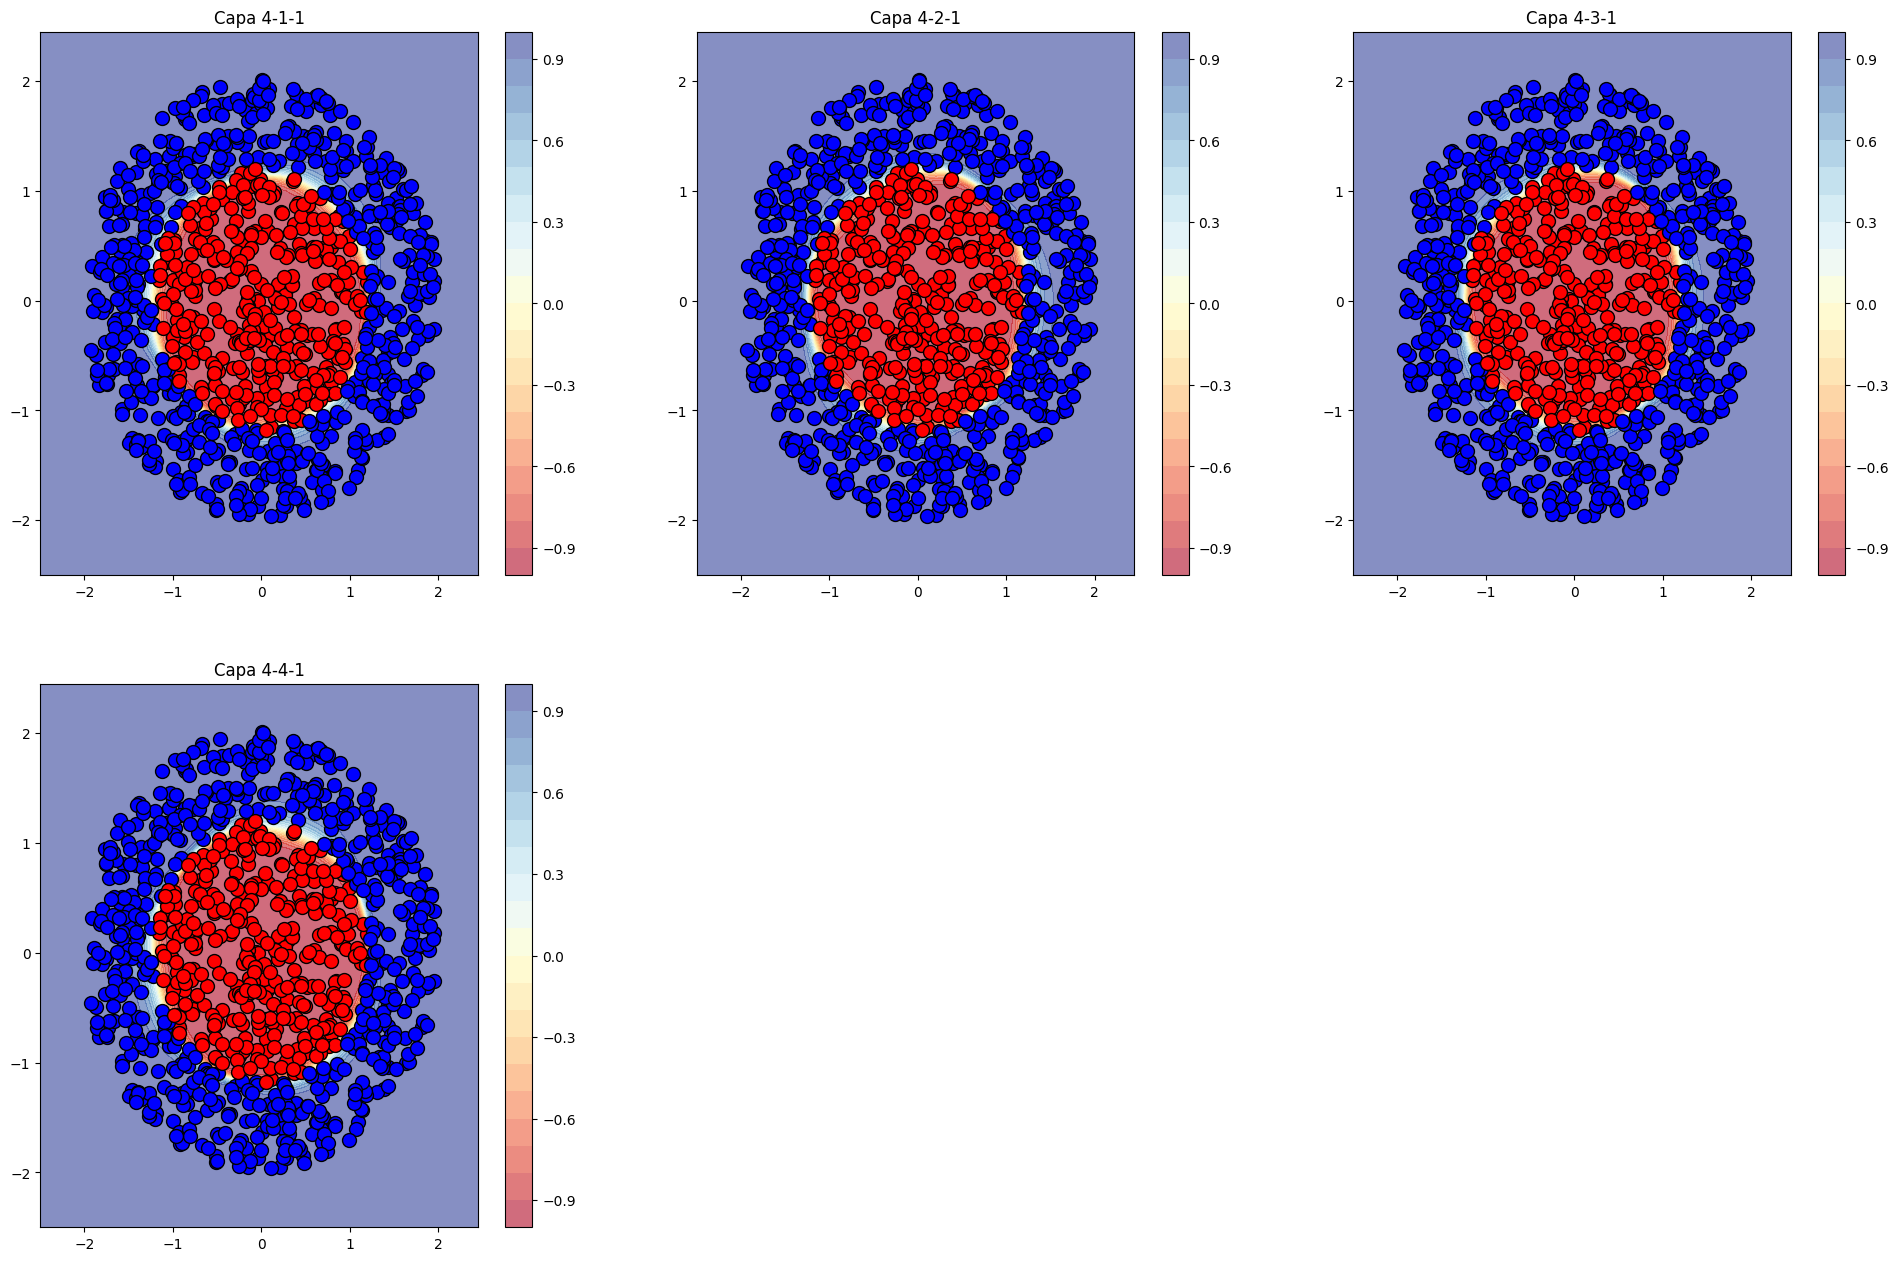

In [12]:
combinaciones = [
    1, 2, 3, 4,
]
plt.figure(figsize=(24,24))

for i in range(len(combinaciones)):
    plt.subplot(3,3,i+1)
    model = neural_network(
        layers_config = [
            (4, 'symmetry sigmoid'),
            (combinaciones[i], 'symmetry sigmoid'),
            (1, 'symmetry sigmoid')
        ],
        size_input = X_train_norm.shape[1],
        max_epoch=100,
        learning_rate=0.01,
        error_threshold=1e-3)

    plt.title(f"Capa 4-{combinaciones[i]}-1")
    model.fit(X_train_norm, y_train)
    graficar_malla(model, plt)